# Genomic language model: 원리에서 Nucleotide Transformer까지

Genomic language model(gLM)은 DNA 서열을 글의 문장처럼 다룹니다. 이 실습에서는 DNA가 모델의 입력이 되고, 모델이 서열을 숫자 벡터로 표현하고, 그 표현을 이용해 서열과 변이를 분석하는 과정을 따라갑니다.

전체 흐름은 다음과 같습니다.

**DNA 서열 → token → masked language modeling → supervised baseline → NT embedding → 변이 효과**

실습이 끝나면 다음을 설명할 수 있어야 합니다.

- DNA 서열을 token으로 나누는 이유
- 서열 자체를 정답으로 사용하는 self-supervised learning의 원리
- 처음부터 학습한 MLP와 pretrained representation의 차이
- Nucleotide Transformer embedding을 분류에 사용하는 방법
- saturation mutagenesis heatmap을 읽는 방법


## 실습은 이렇게 진행합니다

### 1. DNA 서열을 token으로 나눕니다

같은 reference 서열과 변이 서열을 single nucleotide, 3-mer, BPE 방식으로 나눕니다. 한 염기 변이가 token 하나만 바꾸는지, 여러 token이나 token 경계까지 바꾸는지 확인합니다.

**핵심:** 모델은 긴 DNA 문자열을 그대로 보는 것이 아니라 tokenizer가 만든 token을 봅니다.

### 2. 가린 염기를 맞히는 작은 모델을 만듭니다

서열의 중앙 염기를 `[MASK]`로 가리고 작은 MLP가 원래 염기를 맞히도록 학습합니다. 사람이 label을 따로 만들지 않아도 가리기 전 염기가 정답이 됩니다.

**핵심:** self-supervised learning은 데이터 안에서 입력과 정답을 함께 만듭니다.

### 3. 합성 promoter-like 서열을 두 방식으로 분류합니다

Pair마다 무작위 위치에 `TATAAA`를 넣은 promoter-like positive를 만들고, 그 서열 전체를 섞어 shuffled control을 만듭니다. 먼저 raw one-hot 서열만 보는 작은 MLP를 처음부터 학습합니다. 그다음 pretrained NT embedding 위에 linear probe를 학습해 같은 test set에서 비교합니다.

두 모델이 motif 위치가 달라져도 positive와 negative를 구별하는지 ROC-AUC로 확인하고, PCA와 cosine similarity로 NT embedding 공간도 살펴봅니다.

**핵심:** MLP는 이 작은 labeled dataset에서 모든 가중치를 처음부터 학습하지만, NT는 pretraining에서 만든 representation을 고정해 사용합니다.

### 4. 모든 single-nucleotide variant의 효과를 계산합니다

Test 서열 하나를 선택해 180개 위치를 각각 다른 세 염기로 바꿉니다. 만들어진 540개 변이의 점수를 계산하고, 어느 위치의 변이가 분류 점수를 크게 바꾸는지 heatmap으로 확인합니다.

**핵심:** saturation mutagenesis는 모델이 민감하게 반응하는 위치와 염기 변화를 보여 줍니다.

**권장 진행 시간:** tokenization 10분 · MLM 15분 · MLP와 NT 비교 25분 · saturation mutagenesis 15분


## 결과를 해석할 때 주의할 점

이 실습에서는 원리를 쉽게 확인하기 위해 직접 만든 인공 서열을 사용합니다.

- Positive에는 `TATAAA` motif를 넣었습니다.
- Negative는 positive 전체를 섞어 만들었습니다. 따라서 pair 안의 A/C/G/T 개수는 같습니다.
- 여기서 얻은 분류 성능은 이 인공 과제에 대한 결과입니다. 실제 promoter나 enhancer 예측 성능이 아닙니다.
- Saturation mutagenesis 결과도 모델 점수의 변화입니다. 실제 기능이나 질병 위험을 직접 의미하지 않습니다.

실제 연구에서는 실제 genomic region을 사용하고, chromosome 또는 locus 단위로 train과 test를 분리해야 합니다. Genome build, strand, negative set도 함께 기록해야 합니다.


## **0. 환경 준비**

Colab 메뉴에서 **런타임 → 런타임 유형 변경 → T4 GPU**를 선택합니다. 패키지와 모델 revision을 고정해 수강생마다 실행 환경이 달라지는 문제를 줄입니다.

Colab에 기본 설치된 Gradio는 이번 실습에서 사용하지 않으며, 고정한 Transformers와 요구하는 `huggingface-hub` 버전이 다릅니다. 아래 셀은 현재 Colab 세션에서 Gradio 관련 패키지를 먼저 제거한 뒤 NT 실행 환경을 설치합니다. 새 Colab 런타임을 열면 기본 환경은 다시 복구됩니다.


In [1]:
%pip uninstall -q -y gradio gradio-client
%pip install -q "huggingface-hub==0.36.2" "transformers==4.57.1" "accelerate>=1.4,<2" "scikit-learn>=1.5,<2" "seaborn>=0.13,<1"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 53.8 MB/s eta 0:00:00


### 분석 패키지 불러오기

먼저 표와 그림, 배열 계산, 작은 neural network에 필요한 패키지를 불러옵니다. 아직 모델을 학습하거나 NT를 다운로드하지는 않습니다.


In [2]:
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn


scikit-learn은 dataset split, PCA, logistic regression과 평가에 사용합니다. `DataLoader`는 작은 MLM 학습 데이터를 mini-batch로 나눕니다.


In [3]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset


### 재현성과 계산 장치

난수 seed를 고정하면 인공 서열, train/test split, 초기 가중치가 매번 동일하게 만들어집니다. 아래 출력에서 `device: cuda`가 보이면 GPU를 사용하고 있는 것입니다.


In [4]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__, "| device:", DEVICE)


PyTorch: 2.11.0+cu128 | device: cuda


## **1. Tokenization: 변이 하나가 token을 어떻게 바꾸나?**

Language model은 DNA 문자열을 직접 계산하지 않습니다. 먼저 문자열을 token으로 나누고, 각 token을 정수 ID와 embedding vector로 바꿉니다.

여기서는 중앙의 `A>C` 변이가 세 tokenization 방식에서 어떻게 보이는지 비교합니다.


In [5]:
REF_SEQ = "GCGTATAAAGCCATCGTA"
VARIANT_POS = 6                     # 0-based
ALT_SEQ = REF_SEQ[:VARIANT_POS] + "C" + REF_SEQ[VARIANT_POS + 1:]

print("reference :", REF_SEQ)
print("alternative:", ALT_SEQ)
print(" " * (11 + VARIANT_POS) + "^")


reference : GCGTATAAAGCCATCGTA
alternative: GCGTATCAAGCCATCGTA
                 ^


### 1.1 Single nucleotide와 non-overlapping k-mer

Single nucleotide tokenization은 염기 하나가 token 하나입니다. Base-level 변이를 가장 직접적으로 표현하지만 입력 token 수가 길어집니다.

k-mer tokenization은 연속한 k개 염기를 하나의 token으로 묶습니다. 여기서는 경계 변화를 쉽게 보기 위해 non-overlapping 3-mer를 사용합니다.


In [6]:
def single_tokens(seq):
    return list(seq)

def nonoverlap_kmers(seq, k=3):
    return [seq[i:i+k] for i in range(0, len(seq), k)]


### 1.2 장난감 BPE

BPE(Byte Pair Encoding)는 corpus에서 자주 붙어 나오는 token pair를 반복해서 합칩니다. 아래에서는 `TATAAA`가 자주 등장해 하나의 token으로 합쳐졌다고 가정합니다.

실제 BPE는 큰 학습 corpus에서 merge rule과 vocabulary를 학습합니다. 아래 코드는 그 원리만 보여 주는 최소 예제입니다.


In [7]:
# TATAAA가 corpus에서 자주 나타나 하나의 단위로 합쳐졌다고 가정
BPE_MERGES = [
    ("T", "A"),
    ("TA", "TA"),
    ("TATA", "A"),
    ("TATAA", "A"),
]

def toy_bpe(seq, merges=BPE_MERGES):
    tokens = list(seq)
    for left, right in merges:
        merged, i = [], 0
        while i < len(tokens):
            if i + 1 < len(tokens) and tokens[i] == left and tokens[i + 1] == right:
                merged.append(left + right)
                i += 2
            else:
                merged.append(tokens[i])
                i += 1
        tokens = merged
    return tokens


### 1.3 세 방식 비교

각 행에서 reference와 alternative의 token 경계를 비교합니다. `|`가 token 사이의 경계입니다.


In [8]:
tokenizers = {
    "single nucleotide": single_tokens,
    "non-overlap 3-mer": lambda s: nonoverlap_kmers(s, 3),
    "toy BPE": toy_bpe,
}

rows = []
for name, fn in tokenizers.items():
    ref_tok, alt_tok = fn(REF_SEQ), fn(ALT_SEQ)
    rows.append({
        "tokenization": name,
        "reference tokens": " | ".join(ref_tok),
        "alternative tokens": " | ".join(alt_tok),
        "n(ref → alt)": f"{len(ref_tok)} → {len(alt_tok)}",
    })

pd.DataFrame(rows).style.set_properties(
    subset=["reference tokens", "alternative tokens"],
    **{"font-family": "monospace", "text-align": "left"}
)


,tokenization,reference tokens,alternative tokens,n(ref → alt)
0,single nucleotide,G | C | G | T | A | T | A | A | A | G | C | C | A | T | C | G | T | A,G | C | G | T | A | T | C | A | A | G | C | C | A | T | C | G | T | A,18 → 18
1,non-overlap 3-mer,GCG | TAT | AAA | GCC | ATC | GTA,GCG | TAT | CAA | GCC | ATC | GTA,6 → 6
2,toy BPE,G | C | G | TATAAA | G | C | C | A | T | C | G | TA,G | C | G | TA | T | C | A | A | G | C | C | A | T | C | G | TA,12 → 16


**출력 읽기**

- single nucleotide에서는 변이 위치의 token 하나만 바뀝니다.
- 3-mer에서는 해당 염기가 포함된 token 전체가 바뀝니다.
- BPE에서는 `TATAAA`라는 긴 token이 깨지면서 token 내용뿐 아니라 token 수와 경계도 바뀝니다.

따라서 변이 효과를 해석하기 전에 모델의 tokenizer와 token 경계를 확인해야 합니다. 뒤에서 사용할 NT v2는 가능한 구간을 주로 non-overlapping 6-mer로 tokenization합니다.


## **2. Self-supervised learning: 초소형 masked language model**

Masked language modeling(MLM)은 원래 서열의 일부를 가리고 주변 문맥으로 가린 token을 맞히는 과제입니다.

\[
\text{A C G [MASK] A C G} \quad\longrightarrow\quad \text{target: T}
\]

가리기 전 염기가 정답이므로 사람이 별도의 label을 붙일 필요가 없습니다. 이처럼 데이터 자체에서 학습 target을 만드는 것이 self-supervised learning의 핵심입니다.


### 2.1 Vocabulary와 one-hot encoding

입력 vocabulary는 네 염기와 `[MASK]`로 구성합니다. 출력은 원래 염기 `A/C/G/T` 중 하나를 예측하므로 네 class입니다.


In [9]:
BASES = "ACGT"
TOKENS = ["A", "C", "G", "T", "[MASK]"]
token_to_id = {token: i for i, token in enumerate(TOKENS)}
base_to_id = {base: i for i, base in enumerate(BASES)}


### 2.2 학습 예제 만들기

짧은 반복 pattern에서 길이 9 window를 만들고 중앙 염기를 `[MASK]`로 바꿉니다. 원래 중앙 염기는 target으로 저장합니다.

실제 genome의 복잡성을 모사하려는 dataset이 아니라, “input과 label이 어떻게 자동으로 만들어지는가”를 보기 위한 dataset입니다.


In [10]:
def make_masked_examples(n=4000, window_size=9, mutation_rate=0.03, seed=SEED):
    rng = np.random.default_rng(seed)
    patterns = ["ACGT", "TATAAA", "CGCGAT", "GATTACA"]
    center = window_size // 2
    masked_windows, targets = [], []

    for _ in range(n):
        pattern = rng.choice(patterns)
        phase = int(rng.integers(len(pattern)))
        long_seq = (pattern * 20)[phase:phase + window_size]
        seq = list(long_seq)
        for j in range(window_size):
            if rng.random() < mutation_rate:
                seq[j] = rng.choice(list(BASES))

        targets.append(base_to_id[seq[center]])
        seq[center] = "[MASK]"
        masked_windows.append(seq)

    x = np.zeros((n, window_size, len(TOKENS)), dtype=np.float32)
    for i, seq in enumerate(masked_windows):
        for j, token in enumerate(seq):
            x[i, j, token_to_id[token]] = 1.0
    return masked_windows, torch.tensor(x), torch.tensor(targets, dtype=torch.long)


이제 4,000개의 masked example을 만들고 앞의 8개를 확인합니다. `[MASK]` 자리에 들어 있던 염기가 `target` 열에 보입니다.


In [11]:
masked_windows, X_mlm, y_mlm = make_masked_examples()
preview = pd.DataFrame({
    "masked input": [" ".join(x) for x in masked_windows[:8]],
    "target": [BASES[i] for i in y_mlm[:8].tolist()],
})
preview


,masked input,target
0,T A C G [MASK] A C G T,T
1,C G A T [MASK] G C G A,C
2,T A C G [MASK] A C G T,T
3,C A G A [MASK] T A C A,T
4,T A C A [MASK] A T T A,G
5,T T T A [MASK] A G A T,C
6,A C A G [MASK] T T A C,A
7,A T A A [MASK] T A T A,A


### 2.3 Train/validation 분리와 mini-batch

앞의 3,200개는 학습, 뒤의 800개는 validation에 사용합니다. `DataLoader`가 128개씩 mini-batch를 만들어 줍니다.


In [12]:
n_train = 3200
train_loader = DataLoader(
    TensorDataset(X_mlm[:n_train], y_mlm[:n_train]),
    batch_size=128,
    shuffle=True,
)
X_val, y_val = X_mlm[n_train:].to(DEVICE), y_mlm[n_train:].to(DEVICE)


### 2.4 작은 MLP 정의

길이 9의 one-hot input을 펼치면 \(9 \times 5 = 45\)차원입니다. 이를 hidden unit 32개를 거쳐 네 염기의 logit으로 바꿉니다.

이 모델에는 attention이 없습니다. Transformer를 재현하는 것이 아니라 MLM objective만 분리해 이해하기 위한 모델입니다.


In [13]:
tiny_mlm = nn.Sequential(
    nn.Flatten(),
    nn.Linear(9 * len(TOKENS), 32),
    nn.ReLU(),
    nn.Linear(32, len(BASES)),
).to(DEVICE)


### 2.5 MLM 학습

Cross-entropy loss로 정답 염기의 logit을 높입니다. 매 epoch마다 학습 loss와 validation accuracy를 기록합니다.


In [14]:
optimizer = torch.optim.AdamW(tiny_mlm.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()

history = []
for epoch in range(1, 16):
    tiny_mlm.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = loss_fn(tiny_mlm(xb), yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * len(xb)

    tiny_mlm.eval()
    with torch.no_grad():
        val_logits = tiny_mlm(X_val)
        val_acc = (val_logits.argmax(1) == y_val).float().mean().item()
    history.append((epoch, running_loss / n_train, val_acc))

history_df = pd.DataFrame(history, columns=["epoch", "train_loss", "validation_accuracy"])
print(f"chance accuracy = 0.25 | final validation accuracy = {history_df.validation_accuracy.iloc[-1]:.3f}")


chance accuracy = 0.25 | final validation accuracy = 0.971


### 2.6 학습 곡선

왼쪽에서 loss가 감소하는지, 오른쪽에서 validation accuracy가 random guess인 0.25보다 높아지는지 확인합니다.


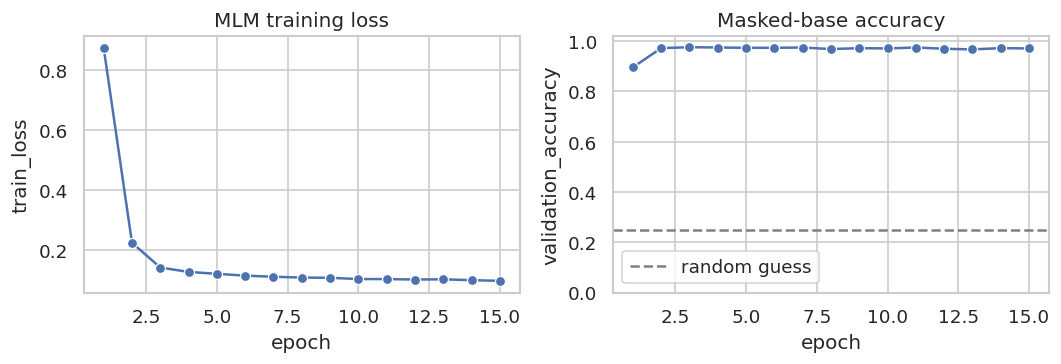

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
sns.lineplot(data=history_df, x="epoch", y="train_loss", marker="o", ax=axes[0])
sns.lineplot(data=history_df, x="epoch", y="validation_accuracy", marker="o", ax=axes[1])
axes[1].axhline(0.25, color="gray", linestyle="--", label="random guess")
axes[0].set_title("MLM training loss")
axes[1].set_title("Masked-base accuracy")
axes[1].set_ylim(0, 1.02)
axes[1].legend()
plt.tight_layout()
plt.show()


### 2.7 실제 masked base 예측

validation example 여덟 개에 대해 가장 확률이 높은 염기와 confidence를 표시합니다. 규칙에서 벗어나도록 무작위 변이가 들어간 위치는 틀릴 수도 있습니다.


In [16]:
tiny_mlm.eval()
with torch.no_grad():
    probs = tiny_mlm(X_val[:8]).softmax(1).cpu().numpy()
result = preview.copy()
result["prediction"] = [BASES[i] for i in probs.argmax(1)]
result["confidence"] = probs.max(1).round(3)
result


,masked input,target,prediction,confidence
0,T A C G [MASK] A C G T,T,A,0.985
1,C G A T [MASK] G C G A,C,T,0.991
2,T A C G [MASK] A C G T,T,T,0.982
3,C A G A [MASK] T A C A,T,T,0.982
4,T A C A [MASK] A T T A,G,A,0.991
5,T T T A [MASK] A G A T,C,T,0.970
6,A C A G [MASK] T T A C,A,T,0.982
7,A T A A [MASK] T A T A,A,C,0.990


### 작은 MLP에서 pretrained genomic model로

방금 모델은 합성 pattern의 짧은 규칙만 학습했습니다. 실제 NT는 같은 self-supervised 아이디어를 대규모 genome corpus와 Transformer에 적용합니다.

NT v2의 BERT-style masking에서는 token의 15%를 학습 대상으로 선택합니다. 선택된 token 중 80%는 mask token, 10%는 random token, 나머지 10%는 원래 token으로 둡니다. 모델은 어느 위치가 바뀌었는지 별도 표식 없이 원래 token을 예측해야 합니다.


## **3. 합성 promoter-like 서열 분류**

`TATAAA`는 일부 진핵생물 promoter에서 전사 시작점 상류에 나타나는 core promoter motif를 단순화한 패턴입니다. 이 실습에는 실제 TSS 좌표가 없고 motif 위치도 의도적으로 무작위화했으므로, positive를 실제 promoter가 아닌 **합성 promoter-like 서열**이라고 부릅니다.

이 과제를 두 방식으로 풉니다. 첫 번째 모델은 raw one-hot 서열에서 모든 가중치를 처음부터 학습하는 작은 MLP입니다. 두 번째는 pretrained NT를 고정한 뒤 embedding 위에 logistic regression만 학습합니다.

### 실험 설계

각 pair마다 0.35에서 0.65 사이의 GC 비율을 무작위로 정합니다.

1. 해당 GC 비율로 길이 180의 random DNA를 만듭니다.
2. 여러 6-mer 경계 중 한 위치를 무작위로 골라 `TATAAA`를 넣고 positive를 만듭니다.
3. 완성된 positive의 180개 염기를 모두 섞습니다.
4. 섞인 서열에 `TATAAA`가 우연히 생기면 다시 섞어 negative를 만듭니다.

이렇게 만든 positive와 negative는 길이, GC content, A/C/G/T 개수가 정확히 같습니다. Motif 위치도 pair마다 달라지므로 분류기가 한 위치만 외워서는 과제를 풀 수 없습니다.


### 3.1 GC 비율과 motif 위치를 무작위로 정하기

원하는 GC 비율에 맞춰 염기를 무작위로 뽑는 `random_dna` 함수를 사용합니다. Pair마다 GC 비율과 motif 위치를 새로 정합니다.

Motif 위치는 6-mer 경계에 맞는 여러 위치 중에서 선택합니다. 위치는 매번 달라지지만 `TATAAA`는 실제 NT tokenizer에서 하나의 6-mer token으로 유지되어 tokenization보다 representation의 차이에 집중할 수 있습니다.


In [17]:
MOTIF = "TATAAA"
SEQ_LEN = 180
# 위치 자체가 label의 지름길이 되지 않도록 pair마다 무작위로 선택합니다.
# NT v2에서 TATAAA가 하나의 6-mer token으로 보이도록 6의 배수만 사용합니다.
MOTIF_POS_CHOICES = np.arange(24, SEQ_LEN - len(MOTIF) - 23, 6)
N_PAIRS = 120
GC_RANGE = (0.35, 0.65)

def replace_site(seq, site, pos):
    return seq[:pos] + site + seq[pos + len(site):]

def random_dna(length, gc, rng):
    probabilities = [(1 - gc) / 2, gc / 2, gc / 2, (1 - gc) / 2]
    return "".join(rng.choice(list(BASES), size=length, p=probabilities))


### 3.2 Paired sequence 생성 함수

Positive가 완성되면 서열 전체를 섞어 negative를 만듭니다. `shuffle_without_motif` 함수는 negative 안에 `TATAAA`가 없을 때까지 다시 섞습니다.


In [18]:
def shuffle_without_motif(seq, rng, max_attempts=10_000):
    letters = np.array(list(seq))
    for _ in range(max_attempts):
        shuffled = "".join(rng.permutation(letters))
        if MOTIF not in shuffled:
            return shuffled
    raise RuntimeError("motif-free shuffled control을 만들지 못했습니다.")

def make_paired_dataset(n_pairs=N_PAIRS, seed=SEED):
    rng = np.random.default_rng(seed)
    records = []
    for pair_id in range(n_pairs):
        motif_pos = int(rng.choice(MOTIF_POS_CHOICES))
        while True:
            target_gc = float(rng.uniform(*GC_RANGE))
            background = random_dna(SEQ_LEN, target_gc, rng)
            positive = replace_site(background, MOTIF, motif_pos)
            if positive.count(MOTIF) == 1:
                break
        negative = shuffle_without_motif(positive, rng)
        for label, source, sequence, class_name in [
            (1, "motif_inserted", positive, "promoter-like"),
            (0, "whole_sequence_shuffle", negative, "shuffled control"),
        ]:
            records.append({
                "pair_id": pair_id,
                "sequence_id": f"pair_{pair_id:03d}_{'pos' if label else 'neg'}",
                "label": label,
                "class_name": class_name,
                "source": source,
                "target_gc": target_gc,
                "motif_pos": motif_pos,
                "sequence": sequence,
            })
    return pd.DataFrame(records)


120개 pair에서 총 240개 서열을 만듭니다. `motif_pos`에는 각 pair에서 선택한 위치를 기록합니다. Negative에도 같은 값을 보관하므로 원래 positive에서 motif가 어디에 있었는지 pair 단위로 추적할 수 있습니다.


In [19]:
df = make_paired_dataset()
df.head(6)


,pair_id,sequence_id,label,class_name,source,target_gc,motif_pos,sequence
0,0,pair_000_pos,1,promoter-like,motif_inserted,0.481664,30,TGATTTACCTGTCAGATGTCTTTACAAGTTTATAAAAGCTGCTTCC...
1,0,pair_000_neg,0,shuffled control,whole_sequence_shuffle,0.481664,30,TAGAAGGCGAATAATGCTATCATTCTTAGGAAAAAAATATAACCGT...
2,1,pair_001_pos,1,promoter-like,motif_inserted,0.475067,84,ACCCCGCTTCCGTGTGGCGAGTAGAGATATTGTTTAGAGAGGCGTT...
3,1,pair_001_neg,0,shuffled control,whole_sequence_shuffle,0.475067,84,TATTCCCTTGCGCTTGTGTGACTTGAACATAGAGGATAGCCCTCAA...
4,2,pair_002_pos,1,promoter-like,motif_inserted,0.449221,54,TACGAAATAAAAGAGGTATGATTATCGTCTCTGACCAACAATGTCT...
5,2,pair_002_neg,0,shuffled control,whole_sequence_shuffle,0.449221,54,TCACGGATATTGATCTCATCACAACCGTGTATAGATATCTGTCCAC...


### 3.3 Dataset quality check

모델을 실행하기 전에 설계 조건이 코드에서 실제로 지켜졌는지 확인합니다.

- positive와 negative가 각각 120개인가?
- 모든 서열 길이가 같은가?
- Pair 안의 A/C/G/T 개수와 GC content가 정확히 같은가?
- motif 위치가 여러 곳에 분산되어 있는가?
- motif가 기록된 위치의 positive에만 존재하는가?


In [20]:
pair_check = (
    df.pivot(index="pair_id", columns="label", values="sequence")
    .rename(columns={0: "shuffled", 1: "motif"})
)
gc = lambda s: (s.count("G") + s.count("C")) / len(s)
paired_gc_delta = [
    gc(motif) - gc(shuffled)
    for shuffled, motif in pair_check[["shuffled", "motif"]].itertuples(index=False)
]
same_composition = [
    sorted(shuffled) == sorted(motif)
    for shuffled, motif in pair_check[["shuffled", "motif"]].itertuples(index=False)
]
positive_rows = df.query("label == 1")

checks = {
    "rows": len(df),
    "class balance": df["label"].value_counts().to_dict(),
    "all lengths identical": df["sequence"].str.len().nunique() == 1,
    "mean GC (negative)": df.query("label == 0")["sequence"].map(gc).mean(),
    "mean GC (positive)": df.query("label == 1")["sequence"].map(gc).mean(),
    "all paired ΔGC == 0": np.allclose(paired_gc_delta, 0),
    "all pairs have identical A/C/G/T counts": all(same_composition),
    "motif positions vary across pairs": positive_rows["motif_pos"].nunique() > 1,
    "all motif positions align to 6-mer boundaries": positive_rows["motif_pos"].mod(6).eq(0).all(),
    "motif appears at every planted position": positive_rows.apply(
        lambda row: row["sequence"][
            row["motif_pos"]:row["motif_pos"] + len(MOTIF)
        ] == MOTIF,
        axis=1,
    ).all(),
    "motif absent from every negative": ~df.query("label == 0")["sequence"].str.contains(MOTIF).any(),
}
pd.Series(checks, name="value").to_frame()


,value
rows,240
class balance,"{1: 120, 0: 120}"
all lengths identical,True
mean GC (negative),0.483148
mean GC (positive),0.483148
all paired ΔGC == 0,True
all pairs have identical A/C/G/T counts,True
motif positions vary across pairs,True
all motif positions align to 6-mer boundaries,True
motif appears at every planted position,True


### 3.4 Group-aware train/test split

같은 pair의 두 서열은 염기 순서는 다르지만 A/C/G/T 개수가 완전히 같습니다. 이 둘은 하나의 대조 실험 단위이므로 train과 test에 나누지 않습니다.

`pair_id`를 group으로 지정해 pair 전체가 train 또는 test 한쪽에만 들어가도록 분리합니다.


In [21]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=SEED)
train_idx, test_idx = next(
    splitter.split(df, y=df["label"], groups=df["pair_id"])
)
df["split"] = "train"
df.loc[test_idx, "split"] = "test"

assert set(df.loc[train_idx, "pair_id"]).isdisjoint(set(df.loc[test_idx, "pair_id"]))
pd.crosstab(df["split"], df["class_name"], margins=True)


class_name,promoter-like,shuffled control,All
split,,,
test,30,30,60
train,90,90,180
All,120,120,240


## 3.5 Raw one-hot MLP baseline

먼저 pretraining을 전혀 사용하지 않는 작은 supervised model을 학습합니다. 각 염기를 A/C/G/T 네 채널의 one-hot vector로 바꾸면 서열 하나의 입력 shape은 `4 × 180`입니다.

MLP는 이 배열을 펼쳐 사용하므로 같은 motif라도 위치가 달라지면 서로 다른 input node에 들어갑니다. 모든 가중치는 현재 train set의 label만 사용해 처음부터 학습합니다.


In [22]:
def one_hot_encode_sequences(sequences):
    base_index = {base: i for i, base in enumerate(BASES)}
    encoded = np.zeros((len(sequences), len(BASES), SEQ_LEN), dtype=np.float32)
    for row, sequence in enumerate(sequences):
        for position, base in enumerate(sequence):
            encoded[row, base_index[base], position] = 1.0
    return torch.tensor(encoded)

X_raw = one_hot_encode_sequences(df["sequence"].tolist())
y = df["label"].to_numpy()

torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
baseline_mlp = nn.Sequential(
    nn.Flatten(),
    nn.Linear(len(BASES) * SEQ_LEN, 64),
    nn.ReLU(),
    nn.Dropout(0.15),
    nn.Linear(64, 2),
).to(DEVICE)

mlp_trainable_params = sum(p.numel() for p in baseline_mlp.parameters())
print("one-hot input:", tuple(X_raw.shape))
print("trainable parameters:", mlp_trainable_params)


one-hot input: (240, 4, 180)
trainable parameters: 46274


Train pair만 40 epoch 동안 학습합니다. Test pair는 학습과 model 선택에 사용하지 않고 마지막 평가에서 한 번만 사용합니다.


In [23]:
baseline_loader = DataLoader(
    TensorDataset(
        X_raw[train_idx],
        torch.tensor(y[train_idx], dtype=torch.long),
    ),
    batch_size=32,
    shuffle=True,
    generator=torch.Generator().manual_seed(SEED),
)
baseline_optimizer = torch.optim.AdamW(
    baseline_mlp.parameters(), lr=1e-3, weight_decay=1e-3
)
baseline_loss_fn = nn.CrossEntropyLoss()

baseline_history = []
for epoch in range(1, 41):
    baseline_mlp.train()
    epoch_loss = 0.0
    for xb, yb in baseline_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        baseline_optimizer.zero_grad()
        loss = baseline_loss_fn(baseline_mlp(xb), yb)
        loss.backward()
        baseline_optimizer.step()
        epoch_loss += loss.item() * len(xb)
    baseline_history.append(epoch_loss / len(train_idx))

baseline_mlp.eval()
with torch.inference_mode():
    mlp_test_logits = baseline_mlp(X_raw[test_idx].to(DEVICE))
    mlp_test_prob = mlp_test_logits.softmax(1)[:, 1].cpu().numpy()
mlp_test_pred = (mlp_test_prob >= 0.5).astype(int)
mlp_auc = roc_auc_score(y[test_idx], mlp_test_prob)
mlp_acc = accuracy_score(y[test_idx], mlp_test_pred)

print(f"raw one-hot MLP ROC-AUC: {mlp_auc:.3f}")
print(f"raw one-hot MLP accuracy: {mlp_acc:.3f}")


raw one-hot MLP ROC-AUC: 0.551
raw one-hot MLP accuracy: 0.600


이 MLP는 단순한 비교선입니다. NT와 architecture가 같지 않으므로 pretraining 효과만 완벽하게 분리한 실험은 아닙니다. 다만 작은 labeled dataset에서 raw sequence만으로 처음부터 학습하는 경우와, 대규모 pretraining으로 만든 representation을 사용하는 경우의 차이를 직관적으로 보여 줍니다.


## 3.6 Nucleotide Transformer v2 50M 로드

모델 repository의 특정 revision과 Transformers 버전을 고정했습니다. 이 모델의 custom architecture를 읽기 위해 `trust_remote_code=True`를 사용합니다.

최초 실행 시 Hugging Face에서 model weight를 다운로드합니다. GPU가 선택되어 있는지 먼저 확인한 뒤 tokenizer와 model을 메모리에 올립니다.


In [24]:
from transformers import AutoModelForMaskedLM, AutoTokenizer

MODEL_NAME = "InstaDeepAI/nucleotide-transformer-v2-50m-multi-species"
# Official compatibility fix merged on 2025-09-16:
# find_pruneable_heads_and_indices is imported from transformers.pytorch_utils.
MODEL_REVISION = "81b29e5786726d891dbf929404ef20adca5b36f1"


아래 셀은 GPU가 잡혔는지 확인합니다. 오류가 나오면 Colab의 런타임 유형을 T4 GPU로 변경한 뒤 이 셀부터 다시 실행합니다.


In [25]:
if not torch.cuda.is_available():
    raise RuntimeError(
        "Nucleotide Transformer 실습에는 GPU가 필요합니다. "
        "Colab에서 런타임 → 런타임 유형 변경 → T4 GPU를 선택한 뒤 다시 실행하세요."
    )


Tokenizer를 먼저 불러오고, 50M model은 float16으로 GPU에 올립니다. `eval()`은 dropout 등을 추론 모드로 바꾸며, `requires_grad_(False)`는 NT 가중치를 업데이트하지 않도록 고정합니다.


In [26]:
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    revision=MODEL_REVISION,
    trust_remote_code=True,
    token=False,
)
nt_model = AutoModelForMaskedLM.from_pretrained(
    MODEL_NAME,
    revision=MODEL_REVISION,
    trust_remote_code=True,
    token=False,
    dtype=torch.float16,
).to(DEVICE).eval()
nt_model.requires_grad_(False)

print("loaded:", MODEL_NAME)
print("hidden size:", nt_model.config.hidden_size)
print("vocabulary size:", nt_model.config.vocab_size)


tokenizer_config.json:   0%|          | 0.00/129 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/101 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

esm_config.py: 0.00B [00:00, ?B/s]

modeling_esm.py: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/224M [00:00<?, ?B/s]

loaded: InstaDeepAI/nucleotide-transformer-v2-50m-multi-species
hidden size: 512
vocabulary size: 4107


### 3.7 실제 NT token 확인

앞에서 직접 만든 3-mer나 toy BPE가 아니라, 실제 NT tokenizer가 positive sequence를 어떻게 자르는지 확인합니다. 이 서열에서 무작위로 선택된 motif 위치를 읽고, 주변 token에 `TATAAA`가 보이는지 살펴봅니다.


In [27]:
example_row = df.query("label == 1").iloc[0]
example = example_row["sequence"]
example_motif_pos = int(example_row["motif_pos"])
encoded = tokenizer(example, return_tensors="pt")
actual_tokens = tokenizer.convert_ids_to_tokens(encoded["input_ids"][0])

print("sequence length:", len(example), "bp")
print("planted motif position:", example_motif_pos)
print("token count including special tokens:", len(actual_tokens))
print("tokens around motif:")
motif_token_index = 1 + example_motif_pos // 6   # first token is <cls>
print(actual_tokens[motif_token_index - 2:motif_token_index + 3])


sequence length: 180 bp
planted motif position: 30
token count including special tokens: 31
tokens around motif:
['TCTTTA', 'CAAGTT', 'TATAAA', 'AGCTGC', 'TTCCGA']


### 3.8 Token embedding을 sequence embedding으로

Transformer의 마지막 layer는 token마다 512차원 vector를 출력합니다. 서열마다 token 수가 다를 수 있으므로, special token과 padding을 제외한 token vector의 평균을 계산해 하나의 sequence embedding으로 만듭니다.

\[
e_{sequence} = \frac{1}{N}\sum_{i=1}^{N} h_i
\]


In [28]:
def nt_embed(sequences, batch_size=32):
    # Mean-pool final hidden states over non-special, non-padding tokens.
    all_embeddings = []
    started = time.time()

    for start in range(0, len(sequences), batch_size):
        seq_batch = sequences[start:start + batch_size]
        batch = tokenizer(
            seq_batch,
            return_tensors="pt",
            padding=True,
            truncation=True,
        )
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)

        with torch.inference_mode(), torch.autocast(
            device_type="cuda", dtype=torch.float16
        ):
            output = nt_model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                encoder_attention_mask=attention_mask,
                output_hidden_states=True,
                return_dict=True,
            )
            hidden = output.hidden_states[-1]

        special_mask = torch.zeros_like(input_ids, dtype=torch.bool)
        for special_id in tokenizer.all_special_ids:
            special_mask |= input_ids.eq(special_id)
        content_mask = attention_mask.bool() & ~special_mask
        content_mask = content_mask.unsqueeze(-1).to(hidden.dtype)

        pooled = (hidden * content_mask).sum(1) / content_mask.sum(1).clamp(min=1)
        all_embeddings.append(pooled.float().cpu().numpy())

    embeddings = np.concatenate(all_embeddings)
    if not np.isfinite(embeddings).all():
        raise ValueError("NT embedding contains NaN or Inf.")
    print(f"embedded {len(sequences)} sequences in {time.time() - started:.1f}s")
    return embeddings


전체 240개 서열을 batch 단위로 embedding합니다. 최종 행렬의 shape은 `(서열 수, hidden size)`여야 합니다.


In [29]:
X_nt = nt_embed(df["sequence"].tolist())
y = df["label"].to_numpy()
print("embedding matrix:", X_nt.shape)


embedded 240 sequences in 1.5s
embedding matrix: (240, 512)


### 3.9 Frozen embedding 위에 linear probe 학습

NT embedding은 바꾸지 않고 logistic regression만 학습합니다. 각 embedding dimension의 scale이 다를 수 있어 train data로 `StandardScaler`를 학습한 뒤 분류기를 연결합니다.


In [30]:
probe = make_pipeline(
    StandardScaler(),
    LogisticRegression(C=0.3, max_iter=3000, random_state=SEED),
)
probe.fit(X_nt[train_idx], y[train_idx])


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression',
                 LogisticRegression(C=0.3, max_iter=3000, random_state=42))])

Held-out test pair에 대해 promoter-like class probability를 계산합니다.

- **ROC-AUC:** threshold와 무관하게 positive가 negative보다 높은 점수를 받는 정도
- **Accuracy:** probability 0.5를 기준으로 분류했을 때 맞힌 비율


In [31]:
test_prob = probe.predict_proba(X_nt[test_idx])[:, 1]
test_pred = (test_prob >= 0.5).astype(int)
test_auc = roc_auc_score(y[test_idx], test_prob)
test_acc = accuracy_score(y[test_idx], test_pred)

print(f"held-out ROC-AUC: {test_auc:.3f}")
print(f"held-out accuracy: {test_acc:.3f}")


held-out ROC-AUC: 0.740
held-out accuracy: 0.667


### 3.10 같은 test set에서 두 방식 비교

Raw one-hot MLP와 NT embedding probe의 ROC-AUC 및 accuracy를 나란히 비교합니다. 두 모델은 같은 train/test pair를 사용합니다.

MLP는 현재 labeled dataset만 보고 모든 가중치를 학습합니다. NT 방식은 대규모 self-supervised pretraining으로 만들어진 embedding을 사용하고, 현재 label로는 linear probe만 학습합니다.


In [32]:
comparison = pd.DataFrame({
    "model": ["Raw one-hot MLP", "Frozen NT + linear probe"],
    "representation": ["one-hot sequence", "pretrained NT embedding"],
    "task-trained parameters": [
        mlp_trainable_params,
        probe.named_steps["logisticregression"].coef_.size
        + probe.named_steps["logisticregression"].intercept_.size,
    ],
    "held-out ROC-AUC": [mlp_auc, test_auc],
    "held-out accuracy": [mlp_acc, test_acc],
})
comparison.style.format({
    "held-out ROC-AUC": "{:.3f}",
    "held-out accuracy": "{:.3f}",
})


,model,representation,task-trained parameters,held-out ROC-AUC,held-out accuracy
0,Raw one-hot MLP,one-hot sequence,46274,0.551,0.600
1,Frozen NT + linear probe,pretrained NT embedding,513,0.740,0.667


### 3.11 Embedding 공간을 2차원으로 보기

PCA는 512차원 embedding의 분산이 큰 방향 두 개를 찾습니다. 색은 class, marker 모양은 train/test split입니다.

PCA에서 두 class가 완전히 분리되지 않더라도 고차원에서는 분류 가능할 수 있으므로, PCA 그림과 classifier 지표를 함께 봅니다.


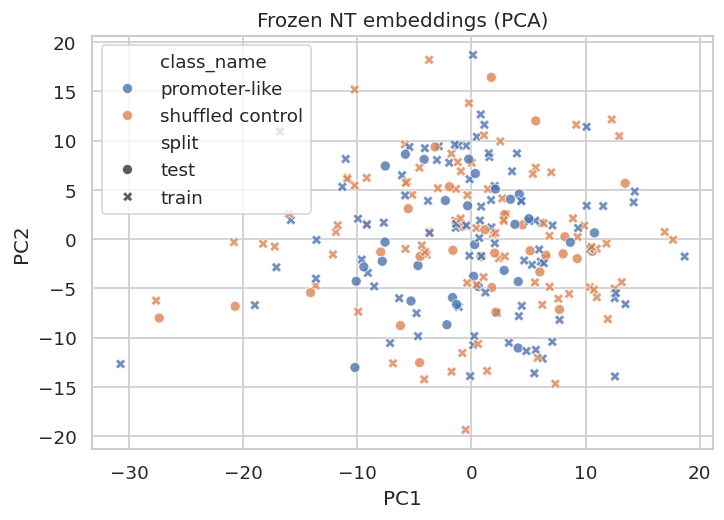

In [33]:
pca = PCA(n_components=2, random_state=SEED)
coords = pca.fit_transform(StandardScaler().fit_transform(X_nt))
plot_df = df.assign(
    PC1=coords[:, 0],
    PC2=coords[:, 1],
    score=probe.predict_proba(X_nt)[:, 1],
)

fig, ax = plt.subplots(figsize=(6.2, 4.5))
sns.scatterplot(
    data=plot_df,
    x="PC1",
    y="PC2",
    hue="class_name",
    style="split",
    alpha=0.8,
    ax=ax,
)
ax.set_title("Frozen NT embeddings (PCA)")
plt.tight_layout()
plt.show()


### 3.12 Cosine similarity로 가까운 서열 찾기

Cosine similarity는 두 embedding vector가 같은 방향을 향하는 정도를 \(-1\)에서 1 사이 값으로 나타냅니다. 각 test sequence에 대해 가장 유사한 **train sequence**를 찾습니다.

Query와 neighbor가 서로 다른 pair에 속하는지도 함께 확인합니다. 이를 통해 classifier를 거치지 않고 NT embedding 공간 자체의 이웃 구조를 살펴볼 수 있습니다.


In [34]:
test_to_train_similarity = cosine_similarity(X_nt[test_idx], X_nt[train_idx])
nearest_train_columns = test_to_train_similarity.argmax(axis=1)

neighbor_rows = []
for test_row, train_col in enumerate(nearest_train_columns):
    query_idx = int(test_idx[test_row])
    neighbor_idx = int(train_idx[train_col])
    neighbor_rows.append({
        "query_pair": int(df.loc[query_idx, "pair_id"]),
        "query_class": df.loc[query_idx, "class_name"],
        "nearest_train_pair": int(df.loc[neighbor_idx, "pair_id"]),
        "nearest_train_class": df.loc[neighbor_idx, "class_name"],
        "cosine_similarity": float(test_to_train_similarity[test_row, train_col]),
        "same_class": bool(df.loc[query_idx, "label"] == df.loc[neighbor_idx, "label"]),
    })

neighbor_df = pd.DataFrame(neighbor_rows)
assert (neighbor_df["query_pair"] != neighbor_df["nearest_train_pair"]).all()
print("same-class nearest-neighbor rate:", round(neighbor_df["same_class"].mean(), 3))
neighbor_df.head(12).style.format({"cosine_similarity": "{:.4f}"})


same-class nearest-neighbor rate: 0.5


,query_pair,query_class,nearest_train_pair,nearest_train_class,cosine_similarity,same_class
0,0,promoter-like,53,promoter-like,0.9821,True
1,0,shuffled control,61,shuffled control,0.9830,True
2,4,promoter-like,74,promoter-like,0.9852,True
3,4,shuffled control,53,promoter-like,0.9877,False
4,10,promoter-like,74,shuffled control,0.9858,False
5,10,shuffled control,105,promoter-like,0.9872,False
6,11,promoter-like,95,shuffled control,0.9813,False
7,11,shuffled control,51,promoter-like,0.9849,False
8,12,promoter-like,74,shuffled control,0.9862,False
9,12,shuffled control,3,shuffled control,0.9875,True


`cosine_similarity`가 높다는 것은 NT가 만든 표현에서 두 서열이 가깝다는 뜻입니다. `same_class` 비율과 개별 mismatch를 함께 보면, embedding이 promoter-like class를 어느 정도 반영하는지와 어떤 예외가 있는지를 확인할 수 있습니다.


### 3.13 Held-out 성능 확인

왼쪽 ROC curve에는 두 모델을 함께 표시합니다. 오른쪽 confusion matrix는 NT embedding probe가 threshold 0.5에서 어떤 예측을 했는지 보여 줍니다.


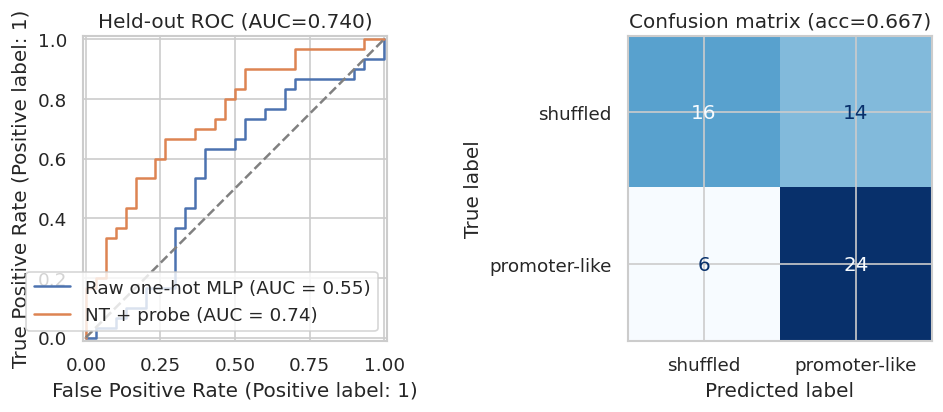

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.6))

RocCurveDisplay.from_predictions(
    y[test_idx], mlp_test_prob, ax=axes[0], name="Raw one-hot MLP"
)
RocCurveDisplay.from_predictions(
    y[test_idx], test_prob, ax=axes[0], name="NT + probe"
)
axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set_title(f"Held-out ROC (AUC={test_auc:.3f})")

ConfusionMatrixDisplay.from_predictions(
    y[test_idx],
    test_pred,
    display_labels=["shuffled", "promoter-like"],
    cmap="Blues",
    colorbar=False,
    ax=axes[1],
)
axes[1].set_title(f"Confusion matrix (acc={test_acc:.3f})")
plt.tight_layout()
plt.show()


## **4. Saturation mutagenesis**

이제 held-out positive 하나를 선택하고, 180개 위치마다 reference가 아닌 세 염기로 바꿉니다. 총 \(180 \times 3 = 540\)개의 SNV가 만들어집니다.

각 mutant를 다시 NT로 embedding하고 probe의 decision function 변화를 계산합니다.

\[
\Delta \text{logit}
= \text{logit(mutant)} - \text{logit(reference)}
\]

Probability가 0이나 1에 가까우면 작은 변화가 눌릴 수 있으므로 변이 비교에는 logit을 사용합니다.


### 4.1 Held-out reference 선택

Test positive 중 probe probability가 중간 정도인 서열을 선택합니다. 가장 점수가 높은 예시만 고르는 것을 피하기 위한 선택입니다.


In [36]:
test_positive_idx = test_idx[y[test_idx] == 1]
positive_scores = probe.predict_proba(X_nt[test_positive_idx])[:, 1]
exemplar_idx = test_positive_idx[np.argsort(positive_scores)[len(positive_scores) // 2]]

ref_seq = df.loc[exemplar_idx, "sequence"]
exemplar_motif_pos = int(df.loc[exemplar_idx, "motif_pos"])
ref_logit = float(probe.decision_function(X_nt[[exemplar_idx]])[0])


### 4.2 모든 single-nucleotide substitution 생성

각 위치에서 reference와 같은 염기는 제외하고 나머지 세 염기로 바꿉니다. `mutants`의 각 행은 위치, reference, alternative와 변이 서열을 포함합니다.


In [37]:
mutant_records = []
for pos, ref_base in enumerate(ref_seq):
    for alt_base in BASES:
        if alt_base == ref_base:
            continue
        mutant_records.append({
            "position": pos,
            "ref": ref_base,
            "alt": alt_base,
            "sequence": ref_seq[:pos] + alt_base + ref_seq[pos + 1:],
        })

mutants = pd.DataFrame(mutant_records)


### 4.3 Mutant embedding과 Δ logit 계산

540개 mutant를 같은 NT와 같은 probe에 통과시킵니다. 행은 alternative base, 열은 sequence position인 4×180 effect matrix로 정리합니다.


In [38]:
X_mut = nt_embed(mutants["sequence"].tolist(), batch_size=32)
mutants["delta_logit"] = probe.decision_function(X_mut) - ref_logit
mutants["in_motif"] = mutants["position"].between(
    exemplar_motif_pos, exemplar_motif_pos + len(MOTIF) - 1
)

effect_matrix = np.full((4, SEQ_LEN), np.nan)
for row in mutants.itertuples():
    effect_matrix[base_to_id[row.alt], row.position] = row.delta_logit

print("reference probe probability:", round(float(probe.predict_proba(X_nt[[exemplar_idx]])[0, 1]), 3))
print("mutants scored:", len(mutants))


embedded 540 sequences in 0.7s
reference probe probability: 0.935
mutants scored: 540


### 4.4 전체 위치와 motif 주변을 함께 보기

위 패널은 위치마다 세 alternative 중 가장 큰 \(|\Delta logit|\)을 보여 줍니다. 아래 패널은 motif 주변을 확대합니다.

- 파란색: mutant가 promoter-like class logit을 낮춤
- 빨간색: mutant가 promoter-like class logit을 높임
- 회색: reference와 동일해 계산하지 않은 염기
- 주황색 영역: 삽입한 `TATAAA`


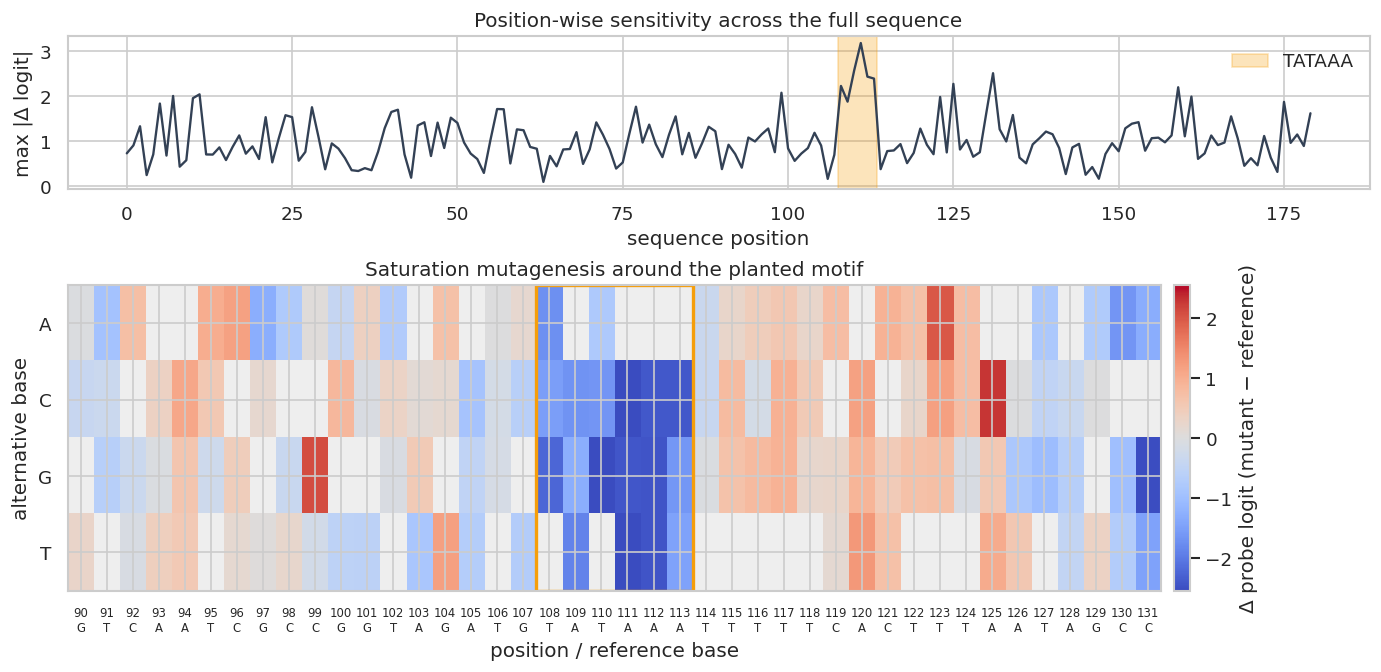

In [39]:
max_abs_by_pos = np.nanmax(np.abs(effect_matrix), axis=0)
zoom_start = max(0, exemplar_motif_pos - 18)
zoom_end = min(SEQ_LEN, exemplar_motif_pos + len(MOTIF) + 18)
zoom = effect_matrix[:, zoom_start:zoom_end]
vmax = max(float(np.nanpercentile(np.abs(zoom), 98)), 1e-6)

cmap = plt.colormaps["coolwarm"].copy()
cmap.set_bad("#eeeeee")

fig = plt.figure(figsize=(14, 6))
grid = fig.add_gridspec(2, 1, height_ratios=[1, 2], hspace=0.42)

ax1 = fig.add_subplot(grid[0])
ax1.plot(np.arange(SEQ_LEN), max_abs_by_pos, color="#334155", linewidth=1.4)
ax1.axvspan(exemplar_motif_pos - 0.5, exemplar_motif_pos + len(MOTIF) - 0.5,
            color="#f59e0b", alpha=0.28, label="TATAAA")
ax1.set(xlabel="sequence position", ylabel="max |Δ logit|",
        title="Position-wise sensitivity across the full sequence")
ax1.legend(frameon=False)

ax2 = fig.add_subplot(grid[1])
im = ax2.imshow(zoom, aspect="auto", cmap=cmap, vmin=-vmax, vmax=vmax)
positions = np.arange(zoom_start, zoom_end)
ax2.set_yticks(range(4), labels=list(BASES))
ax2.set_xticks(range(len(positions)))
ax2.set_xticklabels(
    [f"{p}\n{ref_seq[p]}" for p in positions],
    fontsize=7,
)
ax2.set_xlabel("position / reference base")
ax2.set_ylabel("alternative base")
ax2.set_title("Saturation mutagenesis around the planted motif")
ax2.axvspan(
    exemplar_motif_pos - zoom_start - 0.5,
    exemplar_motif_pos - zoom_start + len(MOTIF) - 0.5,
    facecolor="none", edgecolor="#f59e0b", linewidth=2,
)
cbar = fig.colorbar(im, ax=ax2, pad=0.01)
cbar.set_label("Δ probe logit (mutant − reference)")
plt.show()


### 4.5 영향이 큰 치환 확인

절댓값이 큰 Δ logit 순으로 12개 치환을 정렬합니다. `in_motif=True`가 상위에 많이 나타나는지 확인합니다.


In [40]:
top_effects = (
    mutants.assign(abs_delta=lambda x: x["delta_logit"].abs())
    .sort_values("abs_delta", ascending=False)
    .loc[:, ["position", "ref", "alt", "delta_logit", "in_motif"]]
    .head(12)
)
top_effects.style.format({"delta_logit": "{:+.3f}"})


,position,ref,alt,delta_logit,in_motif
333,111,A,C,-3.182,True
335,111,A,T,-2.691,True
332,110,T,G,-2.573,True
394,131,C,G,-2.512,False
338,112,A,T,-2.435,True
337,112,A,G,-2.429,True
334,111,A,G,-2.414,True
336,112,A,C,-2.403,True
339,113,A,C,-2.392,True
375,125,A,C,+2.275,False


## 정리

- Tokenization은 한 변이가 몇 개 token과 어떤 token 경계를 바꾸는지 결정합니다.
- MLM은 원래 서열에서 input과 target을 만들어 self-supervised learning을 가능하게 합니다.
- Raw one-hot MLP는 작은 labeled dataset에서 모든 가중치를 처음부터 학습하는 비교선입니다.
- Pretrained NT를 고정한 뒤 작은 probe를 학습하면 representation에 downstream task 정보가 있는지 확인할 수 있습니다.
- Saturation mutagenesis는 하나의 점수를 모든 가능한 single-nucleotide substitution에 대해 펼쳐 위치별 민감도로 보여 줍니다.

### 토의 질문

1. Motif 위치 후보를 6의 배수가 아닌 모든 위치로 넓히면 token, 분류 성능, heatmap은 어떻게 달라질까요?
2. Mean pooling 대신 `[CLS]` token이나 max pooling을 사용하면 어떤 정보가 강조될까요?
3. 실제 regulatory sequence를 분류한다면 negative set을 어떻게 구성해야 할까요?
4. Random split 대신 chromosome split이 필요한 이유는 무엇일까요?

### 참고 자료

- Dalla-Torre et al., *The Nucleotide Transformer*, Nature Methods (2025): https://doi.org/10.1038/s41592-024-02523-z
- Hugging Face model card: https://huggingface.co/InstaDeepAI/nucleotide-transformer-v2-50m-multi-species
- Model license: CC-BY-NC-SA-4.0
